#### Setup

In [3]:
import os

import numpy as np
import scipy
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision

import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader

from scipy.stats import binom

torch.set_printoptions(sci_mode=False)

In [4]:
%cd /home/atimans/Desktop/project_erc/erc

/home/atimans/Desktop/project_erc/erc


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

#### Using custom CIFAR-10 pretrained model

These models are taken from [this github](https://github.com/huyvnphan/PyTorch_CIFAR10) and already trained on CIFAR-10, so they are useable off the shelf.

In [6]:
from PyTorch_CIFAR10.cifar10_models.resnet import resnet50

In [7]:
model = resnet50(pretrained=True)
model.to(device)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [8]:
# custom inference transforms for model (see github)
mean = [0.4914, 0.4822, 0.4465]
std = [0.2471, 0.2435, 0.2616]

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# load datasets, and dataloaders with transforms
cifar10_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform)
cifar10_loader = DataLoader(cifar10_dataset, batch_size=64, shuffle=False)

svhn_dataset = datasets.SVHN(root='./data', split='test', transform=transform)
svhn_loader = DataLoader(svhn_dataset, batch_size=64, shuffle=False)

In [9]:
print("Final dataset shape:")
print(f"CIFAR-10: {len(cifar10_loader.dataset), cifar10_loader.dataset.__getitem__(0)[0].shape}")
print(f"SVHN: {len(svhn_loader.dataset), svhn_loader.dataset.__getitem__(0)[0].shape}")

print("\nNr of classes and type:")
print(f"CIFAR-10: {len(cifar10_dataset.classes), cifar10_dataset.classes}")
print(f"SVHN: {len(np.unique(svhn_dataset.labels)), np.unique(svhn_dataset.labels)}")

Final dataset shape:
CIFAR-10: (10000, torch.Size([3, 32, 32]))
SVHN: (26032, torch.Size([3, 32, 32]))

Nr of classes and type:
CIFAR-10: (10, ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])
SVHN: (10, array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]))


In [10]:
# inference and collect predictions
def inference(loader, model):
    print(f"{len(loader.dataset) / loader.batch_size} batches of size {loader.batch_size}.")
    all_preds, all_conf = [], []
    
    with torch.no_grad():
        for images, _ in tqdm(loader, desc="Batch"):
            images = images.to(device)
            out = model(images).to('cpu')
            probs = nn.functional.softmax(out, dim=1)
            preds = torch.argmax(probs, dim=1)
            conf = outlier_score(probs)
            
            all_preds.extend(preds.numpy())
            all_conf.extend(conf.numpy())

    return (
        np.array(all_preds, dtype=np.int32), 
        np.array(all_conf, dtype=np.float32)
    )
    
def outlier_score(probs):
    # top softmax (low top confidence = outlier)
    # score = 1 - torch.max(probs, axis=1)[0]
    
    # normalized entropy (high entropy = outlier)
    score = - torch.sum(probs * torch.log(probs + 1e-10), axis=1) / torch.log(torch.tensor(probs.shape[1]).float())
    
    return score

In [11]:
# run inference on CIFAR-10 (inlier) and SVHN (outlier)
print("Running inference on CIFAR-10 (inlier) dataset...")
cifar10_preds, cifar10_conf = inference(cifar10_loader, model)

print("Running inference on SVHN (outlier) dataset...")
svhn_preds, svhn_conf = inference(svhn_loader, model)

Running inference on CIFAR-10 (inlier) dataset...
156.25 batches of size 64.


Batch: 100%|██████████| 157/157 [00:04<00:00, 32.37it/s]


Running inference on SVHN (outlier) dataset...
406.75 batches of size 64.


Batch: 100%|██████████| 407/407 [00:10<00:00, 38.67it/s]


In [12]:
print(cifar10_preds.shape, cifar10_conf.shape, svhn_preds.shape, svhn_conf.shape)
cifar10_preds[:10], cifar10_conf[:10], svhn_preds[:10], svhn_conf[:10]

(10000,) (10000,) (26032,) (26032,)


(array([3, 8, 8, 0, 6, 6, 1, 6, 3, 1], dtype=int32),
 array([0.04088298, 0.04695556, 0.0521585 , 0.04220984, 0.03846278,
        0.03930046, 0.04144964, 0.03868615, 0.03988957, 0.1317654 ],
       dtype=float32),
 array([3, 3, 3, 5, 3, 3, 5, 0, 3, 5], dtype=int32),
 array([0.40998998, 0.10691661, 0.62084115, 0.5790672 , 0.68884945,
        0.4737729 , 0.12189494, 0.36792052, 0.55023474, 0.04050966],
       dtype=float32))

In [13]:
# compute basic metrics
cifar10_accuracy = (cifar10_preds == cifar10_dataset.targets).mean()
svhn_accuracy = (svhn_preds == svhn_dataset.labels).mean()
print(f"CIFAR-10 accuracy: {cifar10_accuracy:.4f}")
print(f"SVHN accuracy: {svhn_accuracy:.4f}")

print(f"CIFAR-10 mean outlier score: {cifar10_conf.mean():.4f}")
print(f"SVHN mean outlier score: {svhn_conf.mean():.4f}")

CIFAR-10 accuracy: 0.9365
SVHN accuracy: 0.1036
CIFAR-10 mean outlier score: 0.0813
SVHN mean outlier score: 0.2791


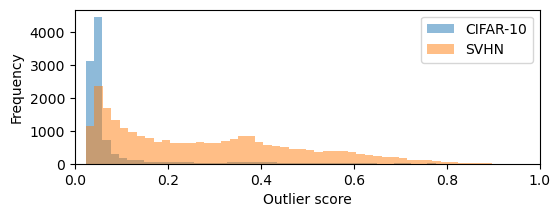

In [14]:
# plot histograms of outlier scores
plt.figure(figsize=(6, 2))
plt.hist(cifar10_conf, bins=50, alpha=0.5, label="CIFAR-10", density=False)
plt.hist(svhn_conf, bins=50, alpha=0.5, label="SVHN", density=False)
plt.xlabel("Outlier score")
plt.ylabel("Frequency")
plt.xlim(0, 1)
plt.legend()
plt.show()

#### Risk control via LTT

Learn-then-Test to determine an outlier threshold $\psi \in [0,1]$ with risk control.

In [15]:
def thresh_grid(min, max, step):
    """Create a grid of threshold values.

    Args:
        min (float): Minimum grid value.
        max (float): Maximum grid value.
        step (float): Step size between grid values.

    Returns:
        torch.Tensor: Grid of threshold values.
    """
    threshs = torch.arange(max, min, -step, dtype=torch.float)
    # every thresh has at most the same number of decimal points as step
    threshs = torch.round(threshs / step) * step
    return threshs


def hb_p_value(risk, n, eps, binary_loss: bool):
    """Compute the p-value of the Hoeffding-Bentkus bound. If binary loss, use the binomial CDF directly.
    Adapted from https://github.com/aangelopoulos/ltt/blob/main/core/bounds.py

    Args:
        risk: Computed risk estimate.
        n: Number of calibration samples.
        eps: Tolerated risk level.

    Returns:
        p-value.
    """
    if binary_loss:
        p_value = binom.cdf(np.ceil(n * risk), n, eps)
    else:
        bentkus_p_value = np.e * binom.cdf(np.ceil(n * risk), n, eps)
        a, b = min(risk, eps), eps
        h1 = a * np.log(a / b) + (1 - a) * np.log((1 - a) / (1 - b))
        hoeffding_p_value = np.exp(-n * h1)
        p_value = min(bentkus_p_value, hoeffding_p_value)

    assert 0 - 1e-4 <= p_value <= 1 + 1e-4, "p-value must be in [0, 1]: {}".format(p_value)
    return p_value


def get_ltt_thresh(losses, eps, delta, binary_loss=False, loss_B=1.0):
    # losses: (N_thresh, N_cal)
    # select thresh closest s.t. LTT p-value is controlled on calibration data
    
    # Note that LTT requires losses in [0, 1], thus we first need to rescale the losses if loss_B > 1
    losses = torch.max(torch.zeros_like(losses), (1 / loss_B) * losses)
    
    N_thresh, N_cal = losses.shape
    risk = losses.mean(dim=1) # (N_thresh,)
    
    pval = torch.zeros((N_thresh,))
    for i in range(N_thresh):
        pval[i] = torch.tensor([hb_p_value(risk[i].item(), N_cal, eps, binary_loss)])
    
    thresh_ids = (pval <= delta).nonzero(as_tuple=True)[0]
    if thresh_ids.shape[0] == 0: # no accept
        thresh_id = torch.tensor([0])
        thresh_ids = torch.tensor([0])
    else:
        thresh_id = thresh_ids[-1] # smallest thresh (from below)
    return thresh_id, thresh_ids, pval


In [16]:
# Define a grid of outlier threshold candidates in the range [0, 1]
thresh_cand = thresh_grid(0, 1, 0.01)
thresh_cand

tensor([1.0000, 0.9900, 0.9800, 0.9700, 0.9600, 0.9500, 0.9400, 0.9300, 0.9200,
        0.9100, 0.9000, 0.8900, 0.8800, 0.8700, 0.8600, 0.8500, 0.8400, 0.8300,
        0.8200, 0.8100, 0.8000, 0.7900, 0.7800, 0.7700, 0.7600, 0.7500, 0.7400,
        0.7300, 0.7200, 0.7100, 0.7000, 0.6900, 0.6800, 0.6700, 0.6600, 0.6500,
        0.6400, 0.6300, 0.6200, 0.6100, 0.6000, 0.5900, 0.5800, 0.5700, 0.5600,
        0.5500, 0.5400, 0.5300, 0.5200, 0.5100, 0.5000, 0.4900, 0.4800, 0.4700,
        0.4600, 0.4500, 0.4400, 0.4300, 0.4200, 0.4100, 0.4000, 0.3900, 0.3800,
        0.3700, 0.3600, 0.3500, 0.3400, 0.3300, 0.3200, 0.3100, 0.3000, 0.2900,
        0.2800, 0.2700, 0.2600, 0.2500, 0.2400, 0.2300, 0.2200, 0.2100, 0.2000,
        0.1900, 0.1800, 0.1700, 0.1600, 0.1500, 0.1400, 0.1300, 0.1200, 0.1100,
        0.1000, 0.0900, 0.0800, 0.0700, 0.0600, 0.0500, 0.0400, 0.0300, 0.0200,
        0.0100])

In [17]:
# Select a random subset of fixed size from the inlier data as calibration set
n_cal = int(0.3 * len(cifar10_preds))
cal_idx = torch.randperm(len(cifar10_preds))[:n_cal]
print(f"Using {n_cal} calibration samples.")
print(cal_idx[:10])

Using 3000 calibration samples.
tensor([8093, 3728, 5086, 6671, 7173, 5823, 1777, 8241, 3368, 8337])


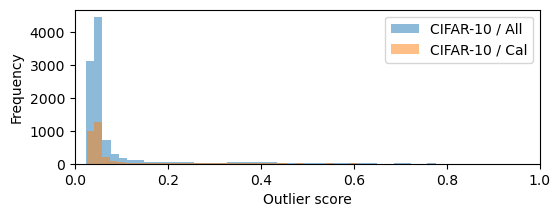

In [18]:
# assert that the calibration set is representative
plt.figure(figsize=(6, 2))
plt.hist(cifar10_conf, bins=50, alpha=0.5, label="CIFAR-10 / All", density=False)
plt.hist(cifar10_conf[cal_idx], bins=50, alpha=0.5, label="CIFAR-10 / Cal", density=False)
plt.xlabel("Outlier score")
plt.ylabel("Frequency")
plt.xlim(0, 1)
plt.legend()
plt.show()

Consider the risk as the total error rate $TER = \frac{\# FP + \# FN}{\# data}$. This could be a relevant risk because it incorporates both inlier and outlier misclassification, whereas something like the FPR only concerns inlier data. But, in the case of only inlier data (as for calibration data) the TER is equal to the $FPR(\mathcal{D}_{cal}) = \frac{\#{FP}}{N_{cal}} \in [0,1]$, and a calibration sample $i$ is classified as $FP$ if its outlier score $out_i > \psi$ since all calibration samples are known to be in-distribution (so there are no FN, i.e., labelling outlier as inlier).

In [19]:
# collect losses in a grid of size (N_thresh, N_cal)

def get_loss(thresh, conf):
    return (conf > thresh)

def get_losses(thresh_cand, conf):
    n_thresh, n_cal = thresh_cand.shape[0], conf.shape[0]
    losses = torch.zeros((n_thresh, n_cal))
    
    for i, thresh in enumerate(thresh_cand):
        losses[i] = get_loss(thresh, conf).to(torch.float32)
    
    return losses

In [20]:
eps = 0.1 # risk level
delta = 0.1 # significance level

losses = get_losses(thresh_cand, torch.tensor(cifar10_conf[cal_idx]))
risk = losses.mean(dim=1)
thresh_id, thresh_ids, pval = get_ltt_thresh(losses, eps, delta, binary_loss=True)

print(f"Selected threshold: {thresh_cand[thresh_id]}, p-value: {pval[thresh_id]}, risk: {risk[thresh_id]}")

Selected threshold: 0.17999999225139618, p-value: 0.08428925275802612, risk: 0.09233333170413971


In [21]:
# visualize risk control decision
def plot_thresh_risk_pval(thresh, risk, pval, rc_psi, epsilon, delta, save_dir=None, save_name=None):
    """
    Plot the risk and p-value as a function of thresh.
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 2.5))
    ax1.plot(thresh, risk, color="black")
    ax1.set_xlim(max(thresh) + 1e-2, 0 - 1e-3)
    ax1.set_xlabel(r"Threshold parameter $\psi$")
    ax1.set_ylabel("Risk")
    ax1.axhline(y=epsilon, color="red", ls=":", label=r"Risk level $\epsilon$", lw=2)
    ax1.axvline(
        x=rc_psi, color="green", ls=":", label=r"Risk controlling $\hat{\psi}$", lw=2
    )
    ax1.legend()

    ax2.plot(thresh, pval, color="black")
    ax2.set_xlim(max(thresh) + 1e-2, 0 - 1e-3)
    ax2.set_xlabel(r"Threshold parameter $\psi$")
    ax2.set_ylabel("P-value")
    ax2.axhline(y=epsilon, color="red", ls=":", label=r"Risk level $\epsilon$", lw=2)
    ax2.axvline(
        x=rc_psi, color="green", ls=":", label=r"Risk controlling $\hat{\psi}$", lw=2
    )
    ax2.legend()

    fig.suptitle(rf"Target guarantee: $\epsilon={epsilon}$, $\delta={delta}$")
    # fname = "thresh_risk_pval.png" if save_name is None else save_name
    # plt.savefig(
    #     os.path.join(save_dir, fname),
    #     bbox_inches="tight",
    # )
    plt.show()


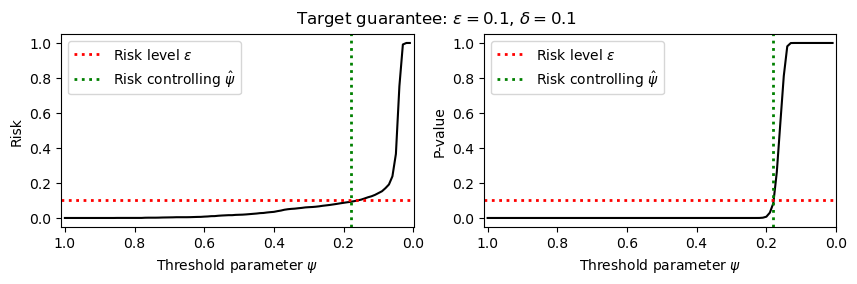

In [22]:
plot_thresh_risk_pval(thresh_cand, risk, pval, thresh_cand[thresh_id], eps, delta)

In [23]:
# Check the selected threshold on the test set
cifar10_test_idx = ~torch.isin(torch.arange(len(cifar10_preds)), cal_idx)
test_losses = get_losses(thresh_cand, torch.Tensor(cifar10_conf)[cifar10_test_idx])
test_risk = test_losses.mean(dim=1)

print(f"Test risk: {test_risk[thresh_id]}")

Test risk: 0.09128571301698685


In [24]:
def plot_test_risk(risk, losses, epsilon, delta, save_dir=None, save_name=None):
    """
    Plot the test risk and loss statistics.
    """
    fig, ax = plt.subplots(1, 1, figsize=(6, 2))
    ax.hist(
        losses,
        bins=30,
        density=True,
        color="lightgray",
        edgecolor="black",
        linewidth=1,
        alpha=0.8,
    )
    ax.set_ylabel("Density")
    ax.set_xlabel("Test losses")
    ax.set_xlim(-0.03, 1.03)
    ax.axvline(x=epsilon, color="red", ls="-", label=r"Risk level $\epsilon$", lw=2)
    ax.axvline(
        x=risk,
        color="green",
        ls="-",
        label=f"Test risk: {risk:.3f}",
        lw=2,
    )
    ax.legend()
    fig.suptitle("Risk control on test data")
    # fname = "test_risk.png" if save_name is None else save_name
    # plt.savefig(
    #     os.path.join(save_dir, fname),
    #     bbox_inches="tight",
    # )
    plt.show()

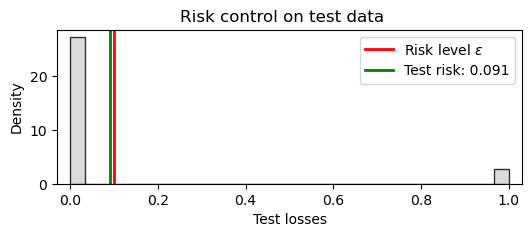

In [25]:
plot_test_risk(test_risk[thresh_id], test_losses[thresh_id], eps, delta)

#### Test stream setting

In [100]:
cifar10_test_idx = ~torch.isin(torch.arange(len(cifar10_preds)), cal_idx)
cifar10_test_labels = torch.Tensor(cifar10_dataset.targets)[cifar10_test_idx]
cifar10_test_preds = torch.Tensor(cifar10_preds)[cifar10_test_idx]
cifar10_test_conf = torch.Tensor(cifar10_conf)[cifar10_test_idx]
id_size = cifar10_test_labels.shape[0]

svhn_test_labels = torch.Tensor(svhn_dataset.labels)
svhn_test_preds = torch.Tensor(svhn_preds)
svhn_test_conf = torch.Tensor(svhn_conf)
ood_size = svhn_test_labels.shape[0]

print("Test set sizes:")
print(f"CIFAR-10: {id_size}")
print(f"SVHN: {ood_size}")

Test set sizes:
CIFAR-10: 7000
SVHN: 26032


In [124]:
T = 3000 # nr of time steps
T_ood = 200 # ood fraction increase every T_ood steps
ood_probs = np.arange(0.05, 1.0, 0.1)
psi_cand = torch.arange(0, 1.01, 0.01)
psi_start = thresh_cand[thresh_id].unsqueeze(0)

stream_bern = torch.zeros(T)
stream_loss = torch.zeros((psi_cand.shape[0], T))
stream_risk = torch.zeros((psi_cand.shape[0], T))

ood_probs, psi_cand, stream_bern.shape, stream_loss.shape

(array([0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95]),
 tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
         0.0900, 0.1000, 0.1100, 0.1200, 0.1300, 0.1400, 0.1500, 0.1600, 0.1700,
         0.1800, 0.1900, 0.2000, 0.2100, 0.2200, 0.2300, 0.2400, 0.2500, 0.2600,
         0.2700, 0.2800, 0.2900, 0.3000, 0.3100, 0.3200, 0.3300, 0.3400, 0.3500,
         0.3600, 0.3700, 0.3800, 0.3900, 0.4000, 0.4100, 0.4200, 0.4300, 0.4400,
         0.4500, 0.4600, 0.4700, 0.4800, 0.4900, 0.5000, 0.5100, 0.5200, 0.5300,
         0.5400, 0.5500, 0.5600, 0.5700, 0.5800, 0.5900, 0.6000, 0.6100, 0.6200,
         0.6300, 0.6400, 0.6500, 0.6600, 0.6700, 0.6800, 0.6900, 0.7000, 0.7100,
         0.7200, 0.7300, 0.7400, 0.7500, 0.7600, 0.7700, 0.7800, 0.7900, 0.8000,
         0.8100, 0.8200, 0.8300, 0.8400, 0.8500, 0.8600, 0.8700, 0.8800, 0.8900,
         0.9000, 0.9100, 0.9200, 0.9300, 0.9400, 0.9500, 0.9600, 0.9700, 0.9800,
         0.9900, 1.0000]),
 torch.Size(

In [125]:
def get_loss(loss_type, psi_cand, bern, lab, pred, conf):
    
    if loss_type == "outlier_fpr_fnr":
        if bern == 0:
            psi_loss = (conf > psi_cand).to(torch.float32) # false positive
        elif bern == 1:
            psi_loss = (conf <= psi_cand).to(torch.float32) # false negative
    
    elif loss_type == "outlier_fnr":
        if bern == 0:
            psi_loss = torch.zeros_like(psi_cand) # no penalty for false positive
        if bern == 1:
            psi_loss = (conf <= psi_cand).to(torch.float32) # false negative
            
    elif loss_type == "outlier_fpr":
        if bern == 0:
            psi_loss = (conf > psi_cand).to(torch.float32) # false positive
        if bern == 1:
            psi_loss = torch.zeros_like(psi_cand) # no penalty for false negative
        
    else:
        raise ValueError(f"Unknown loss type: {loss_type}")
    
    return psi_loss

In [140]:
loss_type = "outlier_fpr_fnr"
ood_idx = 0
ood_prob = ood_probs[ood_idx]

# generate data stream
for t in tqdm(range(0, T), desc="Time step"):
    
    if (t>0) and (t%T_ood == 0) and (t < len(ood_probs) * T_ood):
        print(f"Time step {t}, OOD prob {ood_prob:.2f} -> {ood_probs[ood_idx+1]:.2f}")
        ood_idx += 1
        ood_prob = ood_probs[ood_idx]
    
    # simulate test sample (in or out of distribution)
    bern = np.random.binomial(1, ood_prob)
    if bern == 0:
        i = np.random.randint(0, id_size)
        lab, pred, conf = cifar10_test_labels[i], cifar10_test_preds[i], cifar10_test_conf[i]
    else:
        i = np.random.randint(0, ood_size)
        lab, pred, conf = svhn_test_labels[i], svhn_test_preds[i], svhn_test_conf[i]
    
    stream_bern[t] = bern
    stream_loss[:, t] = get_loss(loss_type, psi_cand, bern, lab, pred, conf)
    
    # stream_risk[:, t] = stream_loss[:, :t+1].mean(dim=1)  
    if loss_type == "outlier_fpr_fnr":
      stream_risk[:, t] = stream_loss[:, :t+1].mean(dim=1)  
    elif loss_type == "outlier_fnr":
      stream_risk[:, t] = stream_loss[:, :t+1].sum(dim=1) / (stream_bern[:t+1].sum() + 1e-10)
    elif loss_type == "outlier_fpr":
        stream_risk[:, t] = stream_loss[:, :t+1].sum(dim=1) / (t - stream_bern[:t+1].sum() + 1e-10)

Time step:  61%|██████    | 1835/3000 [00:00<00:00, 9301.06it/s]

Time step 200, OOD prob 0.05 -> 0.15
Time step 400, OOD prob 0.15 -> 0.25
Time step 600, OOD prob 0.25 -> 0.35
Time step 800, OOD prob 0.35 -> 0.45
Time step 1000, OOD prob 0.45 -> 0.55
Time step 1200, OOD prob 0.55 -> 0.65
Time step 1400, OOD prob 0.65 -> 0.75
Time step 1600, OOD prob 0.75 -> 0.85
Time step 1800, OOD prob 0.85 -> 0.95


Time step: 100%|██████████| 3000/3000 [00:00<00:00, 9447.65it/s]


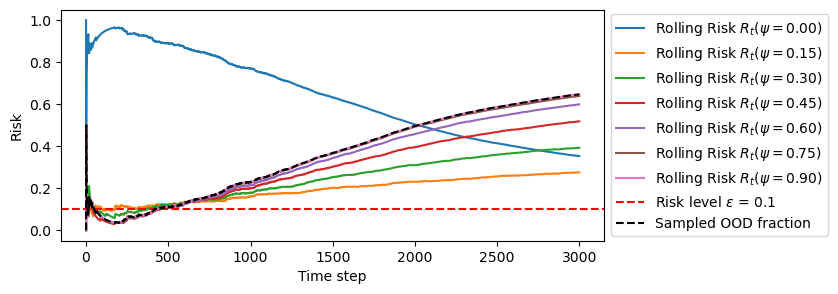

In [141]:
fixed_psi = torch.arange(0, 101, 15)

plt.figure(figsize=(7, 3))
for f_p in fixed_psi:
    r = stream_risk[f_p].numpy()
    plt.plot(r, label=fr"Rolling Risk $R_t(\psi = {psi_cand[f_p]:.2f})$")

plt.axhline(eps, color='red', linestyle='--', label=rf"Risk level $\epsilon$ = {eps}")
plt.plot(torch.cumsum(stream_bern, 0) / (torch.arange(1, T+1) + 1e-10), label="Sampled OOD fraction", color='black', linestyle='--')

plt.xlabel("Time step")
plt.ylabel("Risk")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
# plt.xlim(0, 500)

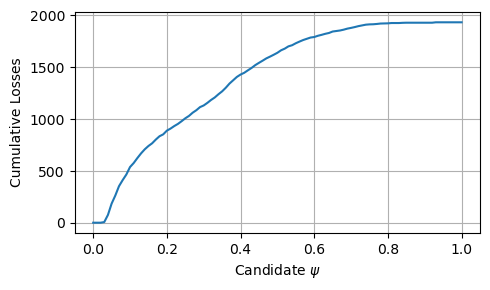

In [139]:
plt.figure(figsize=(5, 3))
plt.plot(psi_cand, stream_loss.sum(dim=1))
plt.xlabel(r"Candidate $\psi$")
plt.ylabel("Cumulative Losses")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Evidence collection

Build wealth process with betting scores $E_t = 1 + \lambda_t \cdot (\ell(X_t, Y_t) - \epsilon)$

Wealth process with product: $W_t = \prod_{s=1}^{t} E_s$

In [131]:
# Find the first occurrence where 10 consecutive indices exist in `tau_emp`
def find_first_consecutive(tau_emp, sequence_length=20):
    for i in range(len(tau_emp) - sequence_length + 1):
        # Check if there is a consecutive sequence of specified length
        if torch.all(tau_emp[i:i + sequence_length] == torch.arange(tau_emp[i], tau_emp[i] + sequence_length)):
            return tau_emp[i]  # Return the starting index of the first robust crossing
    return None  # Return None if no such sequence is found

def get_stopping_time_risk(risk, eps, burn_in=0):
    tau_emp = torch.where(risk[burn_in:] >= eps)[0]
    if len(tau_emp) == 0:
        tau = T
    else:
        first_robust_crossing = find_first_consecutive(tau_emp)
        if first_robust_crossing is None:
            # tau = tau_emp.min() + burn_in
            tau = T
        else:
            tau = first_robust_crossing
    return tau

def get_stopping_time_eprocess(e_process, eps):
    tau_eval = torch.where(e_process >= 1/eps)[0]
    if len(tau_eval) == 0:
        tau = T
    else:
        tau = tau_eval.min()
    return tau

def get_bets(betting_type, T, burn_in=0):
    stream_lam = torch.zeros(T)
    
    if betting_type == "unit_bet":
        stream_lam = torch.ones(T)
    else:
        raise ValueError(f"Unknown betting type: {betting_type}")
    
    stream_lam = torch.cat([torch.zeros(burn_in), stream_lam[:T - burn_in]])
    return stream_lam

In [132]:
stream_lam = get_bets("unit_bet", T, burn_in=0)
stream_eval = torch.ones(T) + stream_lam * (stream_loss - eps)
stream_eprod = torch.cumprod(stream_eval, dim=1)

stream_lam.shape, stream_eval.shape, stream_eprod.shape

(torch.Size([3000]), torch.Size([101, 3000]), torch.Size([101, 3000]))

In [133]:
psi_stop_times = torch.tensor([get_stopping_time_eprocess(stream_eprod[i], eps).item() for i in range(len(psi_cand))])
risk_stop_times = torch.tensor([get_stopping_time_risk(stream_risk[i], eps, burn_in=0).item() for i in range(len(psi_cand))])
detection_delay = psi_stop_times - risk_stop_times

# psi_stop_times, risk_stop_times, detection_delay
detection_delay

tensor([  3,   3,   3,   3,   3,  16,  17,  71,  92,  92, 123, 131, 145, 145,
        146, 239, 238, 239, 221, 347, 347, 260, 693, 677, 674, 676, 651, 654,
        651, 642, 642, 577, 657, 661, 462, 463, 461, 530, 491, 500, 500, 446,
        499, 489, 487, 474, 337, 337, 314, 281, 291, 270, 258, 258, 272, 267,
        255, 241, 272, 272, 272, 274, 274, 260, 289, 289, 284, 284, 284, 284,
        280, 280, 280, 231, 234, 234, 234, 218, 218, 218, 218, 218, 218, 254,
        254, 254, 254, 254, 254, 254, 254, 254, 254, 254, 254, 254, 254, 254,
        254, 254, 254])

In [134]:
psi_cs = []
for t in tqdm(range(1, T+1), desc="Time step"):
    valid_psi = []
    for i, psi in enumerate(psi_cand):
        if t <= psi_stop_times[i]:
            valid_psi.append(psi.item())
    psi_cs.append(valid_psi)

psi_cs_size = [len(valid_psi) for valid_psi in psi_cs]

Time step: 100%|██████████| 3000/3000 [00:02<00:00, 1374.34it/s]


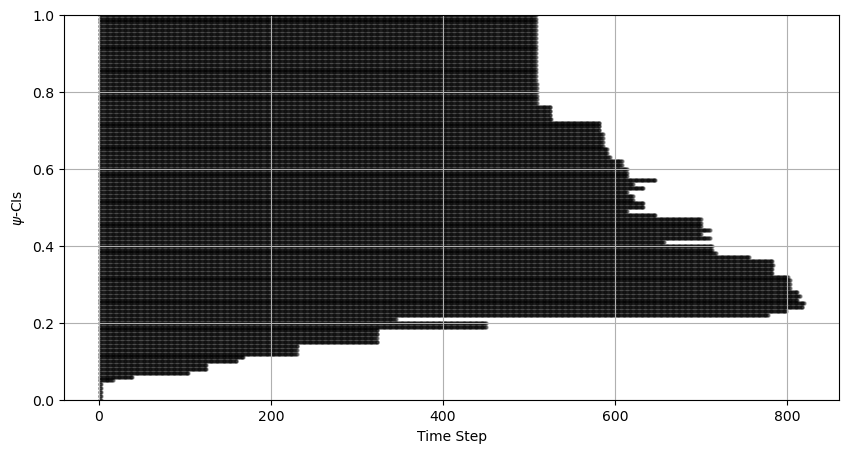

In [135]:
# Generate scatter plot for valid psi values over time steps
plt.figure(figsize=(10, 5))

for t, valid_psi in enumerate(psi_cs, start=1):
    plt.scatter([t] * len(valid_psi), valid_psi, alpha=0.3, color="black", s=5)

plt.xlabel("Time Step")
plt.ylabel(r"$\psi$-CIs")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

/tmp/ipykernel_940561/1134226896.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  axes[1].plot(psi_cand, torch.tensor(detection_delay))


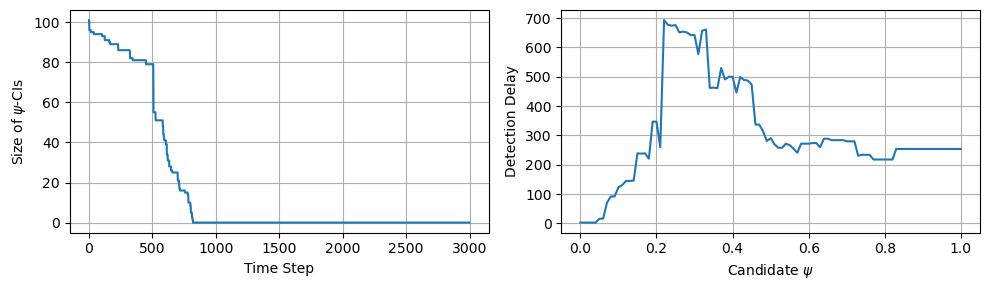

In [136]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Plot psi-CS size on the first subplot
axes[0].plot(torch.tensor(psi_cs_size))
axes[0].set_xlabel("Time Step")
axes[0].set_ylabel(r"Size of $\psi$-CIs")
axes[0].grid(True)

# Plot detection delay on the second subplot
axes[1].plot(psi_cand, torch.tensor(detection_delay))
axes[1].set_ylabel("Detection Delay")
axes[1].set_xlabel(r"Candidate $\psi$")
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Evidence collection (adaptive bets)

Adaptive bet rate at every step $t$: $\lambda_t = \arg \max_{\lambda \in (0, 1/\epsilon)} \sum_{s=1}^{t-1} \log(1 + \lambda \cdot (\ell(X_s, Y_s) - \epsilon))$

In [112]:
lams = thresh_grid(0, (1/eps)-0.1, 0.1)
lam_growth = torch.ones((len(lams), T-1))

for i, lam in enumerate(lams):
    growth = torch.log(torch.ones(T) + lam * (stream_losses - eps))
    lam_growth[i] = torch.cumsum(growth, dim=0)[0:-1] # growth until t-1 for t
    

NameError: name 'stream_losses' is not defined

In [ ]:
lam_init = torch.ones(1)
lam_gr, lam_idx = lam_growth.max(dim=0)
lam_opt = torch.cat([lam_init, lams[lam_idx]])

(0.0, 500.0)

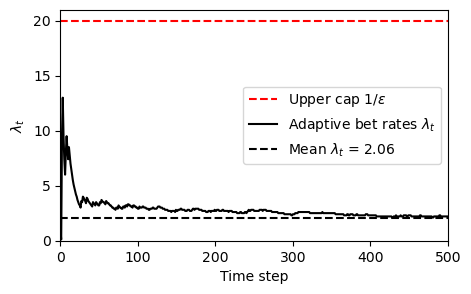

In [ ]:
plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Upper cap $1/\epsilon$")
plt.plot(lam_opt, label=r"Adaptive bet rates $\lambda_t$", color="black")
plt.axhline(y=lam_opt.mean(), color="black", linestyle="--", label=rf"Mean $\lambda_t$ = {lam_opt.mean():.2f}")
plt.legend()

plt.xlabel("Time step")
plt.ylabel(r"$\lambda_t$")
plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
plt.xlim(0, 500)


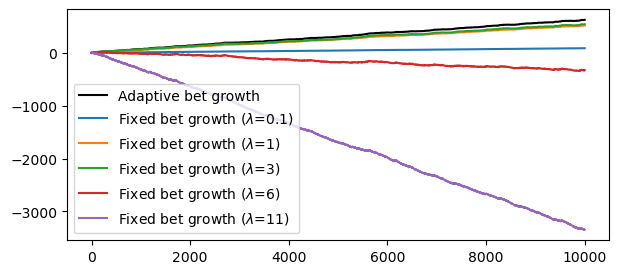

In [ ]:
fixed_lam = [0.1, 1, 3, 6, 11]

plt.figure(figsize=(7, 3))
plt.plot(lam_gr, label=r"Adaptive bet growth", color="black")
for f_l in fixed_lam:
    plt.plot(lam_growth[torch.where(lams == f_l)[0]].squeeze(0), label=rf"Fixed bet growth ($\lambda$={f_l})")    
plt.legend()
# plt.xlim(0, 500)

In [ ]:
stream_eval = torch.ones(T) + lam_opt * (stream_losses - eps)
stream_eprod = torch.cumprod(stream_eval, dim=0)
stream_esum = torch.cumsum(stream_eval, dim=0) / torch.arange(1, T+1)

In [ ]:
stream_eval[:50], stream_eprod[:50], stream_esum[:50]

(tensor([ 0.9500,  1.0950, 10.0250,  0.3500,  0.5250,  0.6300,  6.7000,  8.6000,
          0.5250,  0.5850,  8.0300,  0.5750,  0.6150,  0.6500,  0.6750,  0.7000,
          0.7250,  0.7450,  0.7600,  0.7750,  0.7900,  0.8000,  0.8150,  0.8250,
          0.8350,  0.8400,  3.8500,  0.8200,  4.3250,  0.8000,  0.8050,  0.8150,
          0.8200,  4.2300,  0.8050,  0.8100,  0.8200,  0.8250,  0.8300,  0.8350,
          0.8400,  3.9450,  0.8250,  0.8300,  0.8350,  4.0400,  0.8250,  0.8300,
          0.8350,  0.8400]),
 tensor([  0.9500,   1.0403,  10.4285,   3.6500,   1.9162,   1.2072,   8.0884,
          69.5606,  36.5193,  21.3638, 171.5513,  98.6420,  60.6648,  39.4321,
          26.6167,  18.6317,  13.5080,  10.0634,   7.6482,   5.9274,   4.6826,
           3.7461,   3.0531,   2.5188,   2.1032,   1.7667,   6.8017,   5.5774,
          24.1222,  19.2977,  15.5347,  12.6608,  10.3818,  43.9151,  35.3517,
          28.6349,  23.4806,  19.3715,  16.0783,  13.4254,  11.2773,  44.4891,
          3

Stopping time E-prod: 7
Stopping time E-sum: 10000


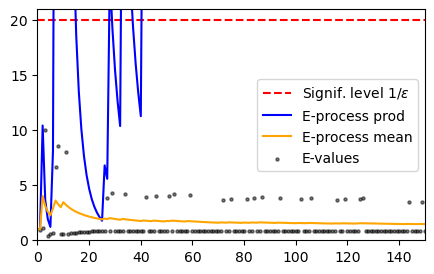

In [ ]:

plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Signif. level $1/\epsilon$")
plt.plot(stream_eprod, label="E-process prod", color="blue")
plt.plot(stream_esum, label="E-process mean", color="orange")
plt.scatter(torch.arange(1, T+1), stream_eval, label="E-values", color="black", s=5, alpha=0.5)
plt.legend()

plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
plt.xlim(0, 150)

print(f"Stopping time E-prod: {get_stopping_time(stream_eprod, eps)}")
print(f"Stopping time E-sum: {get_stopping_time(stream_esum, eps)}")

With burn-in

In [ ]:
burn_in = 100

stream_lam = torch.cat([torch.zeros(burn_in), lam_opt[burn_in:T]])

(0.0, 500.0)

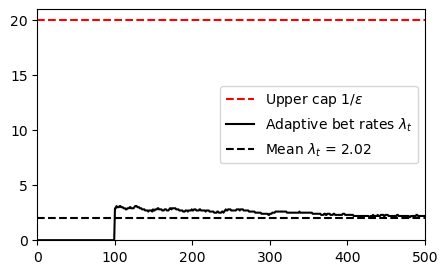

In [ ]:
plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Upper cap $1/\epsilon$")
plt.plot(stream_lam, label=r"Adaptive bet rates $\lambda_t$", color="black")
plt.axhline(y=stream_lam.mean(), color="black", linestyle="--", label=rf"Mean $\lambda_t$ = {stream_lam.mean():.2f}")
plt.legend()

plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
plt.xlim(0, 500)

In [ ]:
stream_eval = torch.ones(T) + stream_lam * (stream_losses - eps)
stream_eprod = torch.cumprod(stream_eval, dim=0)
stream_esum = torch.cumsum(stream_eval, dim=0) / torch.arange(1, T+1)

In [ ]:
stream_eval[75:125], stream_eprod[75:125], stream_esum[75:125]

(tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
         1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 0.8550, 3.7550,
         0.8450, 0.8500, 0.8500, 3.8500, 0.8450, 0.8450, 0.8500, 0.8500, 0.8500,
         0.8550, 0.8550, 0.8550, 0.8600, 3.6600, 0.8550, 0.8550, 3.7550, 0.8500,
         0.8500, 0.8550, 0.8550, 0.8550, 3.7550]),
 tensor([ 1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
          1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
          1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,
          1.0000,  0.8550,  3.2105,  2.7129,  2.3060,  1.9601,  7.5463,  6.3766,
          5.3882,  4.5800,  3.8930,  3.3090,  2.8292,  2.4190,  2.0682,  1.7787,
          6.5100,  5.5660,  4.7590, 17.8699, 15.1894, 12.9110, 11.0389,  9.4383,
          8.0697, 30.3018]),
 tensor([1.0000, 1.0000, 1.00

Stopping time E-prod: 124
Stopping time E-sum: 10000


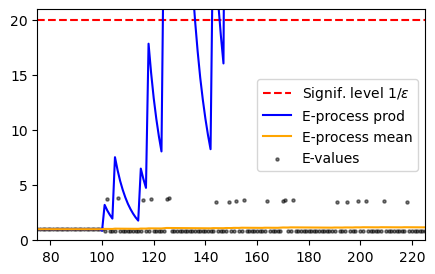

In [ ]:
plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Signif. level $1/\epsilon$")
plt.plot(stream_eprod, label="E-process prod", color="blue")
plt.plot(stream_esum, label="E-process mean", color="orange")
plt.scatter(torch.arange(1, T+1), stream_eval, label="E-values", color="black", s=5, alpha=0.5)
plt.legend()

plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
plt.xlim(75, 225)

print(f"Stopping time E-prod: {get_stopping_time(stream_eprod, eps)}")
print(f"Stopping time E-sum: {get_stopping_time(stream_esum, eps)}")

#### Updating mechanism

Once the stopping threshold is met, an update to the initial risk-controlling threshold $\psi$ is triggered. One trivial update for the fixed OOD proportion setting could be to update calibration set with labelled examples and recompute $\psi$.

In [ ]:
# stop_time = get_stopping_time(stream_eprod, eps).item()
stop_time = 1000

test_ood_mask = (stream_bern[:stop_time] == 1)
test_ood_idx = stream_idx[:stop_time][test_ood_mask].int()
test_id_idx = stream_idx[:stop_time][~test_ood_mask].int()

print(f"Stopping time: {stop_time} | OOD samples: {test_ood_mask.sum()} | ID samples: {test_ood_mask.shape[0] - test_ood_mask.sum()}")

Stopping time: 1000 | OOD samples: 148 | ID samples: 852


In [ ]:
print("Incorporating test samples (both ID and OOD) into calibration set.")

losses = get_losses(thresh_cand, torch.cat([
    torch.Tensor(cifar10_conf[cal_idx]), torch.Tensor(cifar10_conf[test_id_idx]), torch.Tensor(svhn_conf[test_ood_idx])
    ])
                    )
losses[:, -len(test_ood_idx):] = 1.0 - losses[:, -len(test_ood_idx):] # FN: outlier as inlier
risk = losses.mean(dim=1)

thresh_id, thresh_ids, pval = get_ltt_thresh(losses, eps, delta, binary_loss=True)

print(f"Selected threshold: {thresh_cand[thresh_id]}, p-value: {pval[thresh_id]}, risk: {risk[thresh_id]}")


Incorporating test samples (both ID and OOD) into calibration set.
Selected threshold: 0.5799999833106995, p-value: 0.08827460557222366, risk: 0.04500000178813934


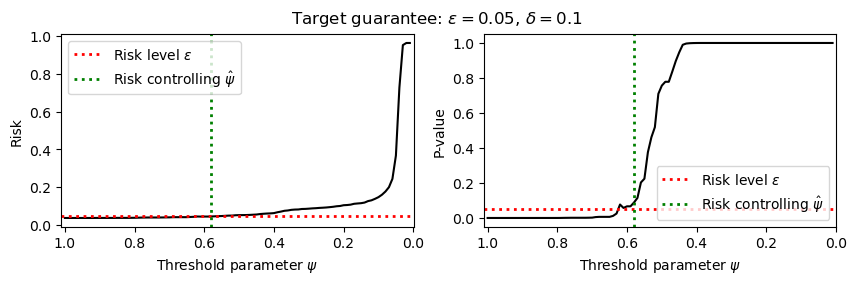

In [ ]:
plot_thresh_risk_pval(thresh_cand, risk, pval, thresh_cand[thresh_id], eps, delta)

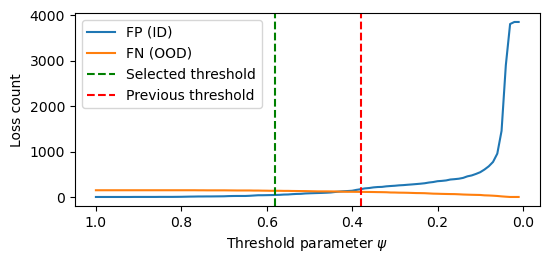

In [ ]:
plt.figure(figsize=(6, 2.5))
plt.plot(thresh_cand, losses[:, :-len(test_ood_idx)].sum(dim=1), label="FP (ID)")
plt.plot(thresh_cand, losses[:, -len(test_ood_idx):].sum(dim=1), label="FN (OOD)")
plt.axvline(thresh_cand[thresh_id], color="green", linestyle="--", label="Selected threshold")
plt.axvline(thresh, color="red", linestyle="--", label="Previous threshold")
plt.xlabel(r"Threshold parameter $\psi$")
plt.gca().invert_xaxis()
plt.ylabel("Loss count")
plt.legend()

The higher number of FN for larger thresholds adds to a heavier tail mass of the risk, pushing the threshold up. In turn, the FP are controlled even stronger to counteract this effect.

The previous setting's risk definition seems suboptimal because it converges to a fixed error proportion over time since it is a fraction with both changing numerator and denominator. Since the fraction is above the risk level, the goal of the e-process becomes simply to reject the null as fast as possible, and can be interpreted as a signal on non-representativity of the calibration data. With enough calibration set updates, the data should become representative enough of the fixed outlier proportion to tune the threshold appropriately. Also, the total error rate has competing interests in terms of FP and FN which want to push the threshold either way?

Instead it seems more sensible to have a risk definition with a growing profile, such that the risk starts at zero and grows over time. This could be achieved by either (1) using a risk that is formulated in terms of some counter (but has to be in [0,1]?) or using a fraction with a fixed denominator, or (2) introducing a shifting outlier proportion over time such that the numerator grows consistently. Then we should also see that the averaging-style e-process does something meaningful. BUT: it will still grow as fast as possible and unrelated to the risk growth profile, since the risk growth is not incorporated anywhere in the wealth process (e.g. through the betting function).

#### With growing OOD fraction

In [ ]:
ood_probs = 1 - thresh_grid(0, 1, 0.01)
ood_probs

tensor([0.0000, 0.0100, 0.0200, 0.0300, 0.0400, 0.0500, 0.0600, 0.0700, 0.0800,
        0.0900, 0.1000, 0.1100, 0.1200, 0.1300, 0.1400, 0.1500, 0.1600, 0.1700,
        0.1800, 0.1900, 0.2000, 0.2100, 0.2200, 0.2300, 0.2400, 0.2500, 0.2600,
        0.2700, 0.2800, 0.2900, 0.3000, 0.3100, 0.3200, 0.3300, 0.3400, 0.3500,
        0.3600, 0.3700, 0.3800, 0.3900, 0.4000, 0.4100, 0.4200, 0.4300, 0.4400,
        0.4500, 0.4600, 0.4700, 0.4800, 0.4900, 0.5000, 0.5100, 0.5200, 0.5300,
        0.5400, 0.5500, 0.5600, 0.5700, 0.5800, 0.5900, 0.6000, 0.6100, 0.6200,
        0.6300, 0.6400, 0.6500, 0.6600, 0.6700, 0.6800, 0.6900, 0.7000, 0.7100,
        0.7200, 0.7300, 0.7400, 0.7500, 0.7600, 0.7700, 0.7800, 0.7900, 0.8000,
        0.8100, 0.8200, 0.8300, 0.8400, 0.8500, 0.8600, 0.8700, 0.8800, 0.8900,
        0.9000, 0.9100, 0.9200, 0.9300, 0.9400, 0.9500, 0.9600, 0.9700, 0.9800,
        0.9900])

In [ ]:
stream_bern = torch.zeros(T)
stream_idx = torch.zeros(T)
stream_losses = torch.zeros(T)

ood_idx = 0

# generate data stream
for t in tqdm(range(0, T), desc="Time step"):
    
    ood_prob = ood_probs[ood_idx]
    if (t>0) and (t%100 == 0):
        ood_idx += 1
    
    # simulate test sample (in or out of distribution)
    bern = np.random.binomial(1, ood_prob)
    
    if bern == 0: # in distribution
        i = np.random.randint(0, cifar10_test_losses.shape[1])
        loss = cifar10_test_losses[thresh_id, i] # FP: inlier as outlier
    else: # out of distribution
        i = np.random.randint(0, svhn_test_losses.shape[1])
        loss = 1.0 - svhn_test_losses[thresh_id, i] # FN: outlier as inlier
    
    stream_bern[t] = bern
    stream_idx[t] = i
    stream_losses[t] = loss

Time step: 100%|██████████| 10000/10000 [00:00<00:00, 15434.26it/s]


In [ ]:
stream_risk = torch.cumsum(stream_losses, dim=0) / torch.arange(1, T + 1)
# stream_risk = torch.cumsum(stream_losses, dim=0) / T

(0.0, 1500.0)

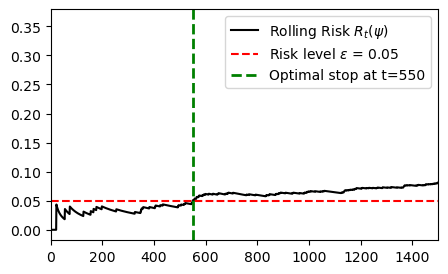

In [ ]:
plt.figure(figsize=(5, 3))
plt.plot(stream_risk, label=r"Rolling Risk $R_{t}(\psi)$", color='black')
# plt.axhline(stream_losses.mean(), color='green', linestyle='--', label=rf"Risk $R(\psi)$ = {stream_losses.mean():.2f}")
plt.axhline(eps, color='red', linestyle='--', label=rf"Risk level $\epsilon$ = {eps}")
stop = torch.where(stream_risk >= eps)[0][0].item()
plt.axvline(stop, color='green', linestyle='--', label=rf"Optimal stop at t={stop}", lw=2)
plt.legend()

# plt.ylim(0.0, 0.2)
plt.xlim(0, 1500)

In [ ]:
torch.where(stream_risk >= eps)[0][0].item()

550

In [ ]:
stream_lam = torch.ones(T)

In [ ]:
stream_eval = torch.ones(T) + stream_lam * (stream_losses - eps)
stream_eprod = torch.cumprod(stream_eval, dim=0)
stream_esum = torch.cumsum(stream_eval, dim=0) / torch.arange(1, T+1)

In [ ]:
stream_eval[:50], stream_eprod[:50], stream_esum[:50]

(tensor([0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500,
         0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500,
         0.9500, 0.9500, 0.9500, 0.9500, 1.9500, 0.9500, 0.9500, 0.9500, 0.9500,
         0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500,
         0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500,
         0.9500, 0.9500, 0.9500, 0.9500, 0.9500]),
 tensor([0.9500, 0.9025, 0.8574, 0.8145, 0.7738, 0.7351, 0.6983, 0.6634, 0.6302,
         0.5987, 0.5688, 0.5404, 0.5133, 0.4877, 0.4633, 0.4401, 0.4181, 0.3972,
         0.3774, 0.3585, 0.3406, 0.3235, 0.6309, 0.5993, 0.5694, 0.5409, 0.5139,
         0.4882, 0.4638, 0.4406, 0.4185, 0.3976, 0.3777, 0.3589, 0.3409, 0.3239,
         0.3077, 0.2923, 0.2777, 0.2638, 0.2506, 0.2381, 0.2262, 0.2149, 0.2041,
         0.1939, 0.1842, 0.1750, 0.1663, 0.1579]),
 tensor([0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500, 0.9500,
       

Stopping time E-prod: 1367
Stopping time E-sum: 10000


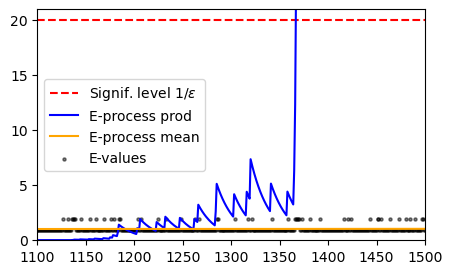

In [ ]:
plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Signif. level $1/\epsilon$")
plt.plot(stream_eprod, label="E-process prod", color="blue")
plt.plot(stream_esum, label="E-process mean", color="orange")
plt.scatter(torch.arange(1, T+1), stream_eval, label="E-values", color="black", s=5, alpha=0.5)
plt.legend()

plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
plt.xlim(1100, 1500)

print(f"Stopping time E-prod: {get_stopping_time(stream_eprod, eps)}")
print(f"Stopping time E-sum: {get_stopping_time(stream_esum, eps)}")

With growth-maximizing adaptive bets

In [ ]:
lams = thresh_grid(0, (1/eps)-0.1, 0.1)
lam_growth = torch.ones((len(lams), T-1))

for i, lam in enumerate(lams):
    growth = torch.log(torch.ones(T) + lam * (stream_losses - eps))
    lam_growth[i] = torch.cumsum(growth, dim=0)[0:-1] # growth until t-1 for t
    

In [ ]:
lam_init = torch.ones(1)
lam_gr, lam_idx = lam_growth.max(dim=0)
lam_opt = torch.cat([lam_init, lams[lam_idx]])

(-0.01, 21.0)

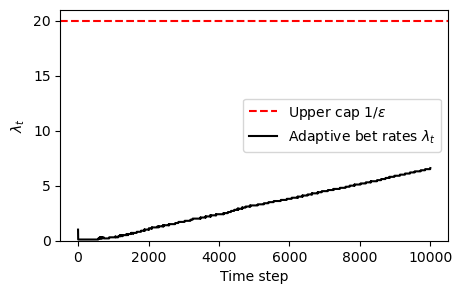

In [ ]:
plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Upper cap $1/\epsilon$")
plt.plot(lam_opt, label=r"Adaptive bet rates $\lambda_t$", color="black")
# plt.axhline(y=lam_opt.mean(), color="black", linestyle="--", label=rf"Mean $\lambda_t$ = {lam_opt.mean():.2f}")
plt.legend()

plt.xlabel("Time step")
plt.ylabel(r"$\lambda_t$")
plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
# plt.xlim(0, 1500)


In [ ]:
stream_eval = torch.ones(T) + lam_opt * (stream_losses - eps)
stream_eprod = torch.cumprod(stream_eval, dim=0)
stream_esum = torch.cumsum(stream_eval, dim=0) / torch.arange(1, T+1)

In [ ]:
stream_eval[:50], stream_eprod[:50], stream_esum[:50]

(tensor([0.9500, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950,
         0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950,
         0.9950, 0.9950, 0.9950, 0.9950, 1.0950, 0.9950, 0.9950, 0.9950, 0.9950,
         0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950,
         0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950, 0.9950,
         0.9950, 0.9950, 0.9950, 0.9950, 0.9950]),
 tensor([0.9500, 0.9452, 0.9405, 0.9358, 0.9311, 0.9265, 0.9219, 0.9172, 0.9127,
         0.9081, 0.9036, 0.8990, 0.8945, 0.8901, 0.8856, 0.8812, 0.8768, 0.8724,
         0.8680, 0.8637, 0.8594, 0.8551, 0.9363, 0.9316, 0.9270, 0.9223, 0.9177,
         0.9131, 0.9086, 0.9040, 0.8995, 0.8950, 0.8905, 0.8861, 0.8817, 0.8772,
         0.8729, 0.8685, 0.8642, 0.8598, 0.8555, 0.8513, 0.8470, 0.8428, 0.8386,
         0.8344, 0.8302, 0.8260, 0.8219, 0.8178]),
 tensor([0.9500, 0.9725, 0.9800, 0.9837, 0.9860, 0.9875, 0.9886, 0.9894, 0.9900,
       

Stopping time E-prod: 1138
Stopping time E-sum: 10000


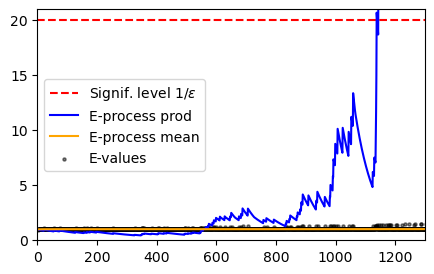

In [ ]:
plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Signif. level $1/\epsilon$")
plt.plot(stream_eprod, label="E-process prod", color="blue")
plt.plot(stream_esum, label="E-process mean", color="orange")
plt.scatter(torch.arange(1, T+1), stream_eval, label="E-values", color="black", s=5, alpha=0.5)
plt.legend()

plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
plt.xlim(0, 1300)

print(f"Stopping time E-prod: {get_stopping_time(stream_eprod, eps)}")
print(f"Stopping time E-sum: {get_stopping_time(stream_esum, eps)}")

With risk-adaptive betting function

Consider a betting function of the form $\lambda = \frac{1}{\alpha(\epsilon - \hat{R}(\psi))}$ clamped to $[0, 1/\epsilon)$. The scale parameter $\alpha$ dictates how aggressive the difference is penalized, with smaller $\alpha < 1$ scaling disproportionately, and bets reducing in aggression as $\alpha > 1$ become larger.

(0.0, 700.0)

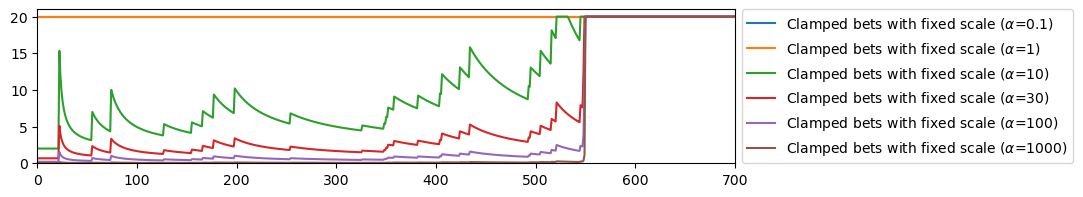

In [ ]:
alphas = [0.1, 1, 10, 30, 100, 1000]

plt.figure(figsize=(9, 2))
for a in alphas:
    bets = (1/(a * (eps - stream_risk)))
    bets_clamp = torch.where((bets > 1/eps) | (bets < 0), torch.tensor(1/eps), bets)
    plt.plot(bets_clamp, label=rf"Clamped bets with fixed scale ($\alpha$={a})")    
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylim(-0.01, 1/eps + 1)
plt.xlim(0, 700)

(0.0, 700.0)

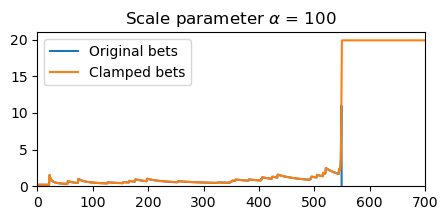

In [ ]:
alpha = 100
bets = 1/(alpha * (eps - stream_risk))
bets_clamp = torch.where((bets >= 1/eps) | (bets < 0), torch.tensor((1/eps)-0.1), bets)

plt.figure(figsize=(5, 2))
plt.title(rf"Scale parameter $\alpha$ = {alpha}")
plt.plot(bets, label="Original bets")
plt.plot(bets_clamp, label="Clamped bets")
plt.legend()

plt.ylim(-0.01, 1/eps + 1)
plt.xlim(0, 700)

In [ ]:
stream_eval = torch.ones(T) + bets_clamp * (stream_losses - eps)
stream_eprod = torch.cumprod(stream_eval, dim=0)
stream_esum = torch.cumsum(stream_eval, dim=0) / torch.arange(1, T+1)

In [ ]:
stream_eval[:50], stream_eprod[:50], stream_esum[:50]

(tensor([0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900,
         0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900,
         0.9900, 0.9900, 0.9900, 0.9900, 2.4567, 0.9400, 0.9500, 0.9567, 0.9614,
         0.9650, 0.9678, 0.9700, 0.9718, 0.9733, 0.9746, 0.9757, 0.9767, 0.9775,
         0.9782, 0.9789, 0.9795, 0.9800, 0.9805, 0.9809, 0.9813, 0.9817, 0.9820,
         0.9823, 0.9826, 0.9829, 0.9831, 0.9833]),
 tensor([0.9900, 0.9801, 0.9703, 0.9606, 0.9510, 0.9415, 0.9321, 0.9227, 0.9135,
         0.9044, 0.8953, 0.8864, 0.8775, 0.8687, 0.8601, 0.8515, 0.8429, 0.8345,
         0.8262, 0.8179, 0.8097, 0.8016, 1.9693, 1.8512, 1.7586, 1.6824, 1.6175,
         1.5609, 1.5106, 1.4653, 1.4240, 1.3860, 1.3508, 1.3180, 1.2873, 1.2583,
         1.2309, 1.2049, 1.1802, 1.1566, 1.1340, 1.1124, 1.0916, 1.0716, 1.0523,
         1.0337, 1.0157, 0.9983, 0.9814, 0.9650]),
 tensor([0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900, 0.9900,
       

Stopping time E-prod: 550
Stopping time E-sum: 10000


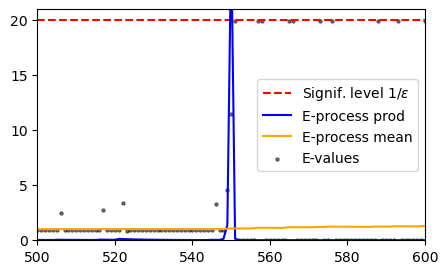

In [ ]:
plt.figure(figsize=(5, 3))
plt.axhline(y=1/eps, color="red", linestyle="--", label=r"Signif. level $1/\epsilon$")
plt.plot(stream_eprod, label="E-process prod", color="blue")
plt.plot(stream_esum, label="E-process mean", color="orange")
plt.scatter(torch.arange(1, T+1), stream_eval, label="E-values", color="black", s=5, alpha=0.5)
plt.legend()

plt.ylim(-0.01, 1/eps + 1)
# plt.ylim(-0.01, 2)
plt.xlim(500, 600)

print(f"Stopping time E-prod: {get_stopping_time(stream_eprod, eps)}")
print(f"Stopping time E-sum: {get_stopping_time(stream_esum, eps)}")

It seems to react well, but now the test becomes very dependent on the scale parameter. Also, we are essentially doing changepoint detection.